In [1]:
from sklearn.datasets import make_classification
import numpy as np
x,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False
                        ,class_sep=10)

In [2]:
import matplotlib.pyplot as plt

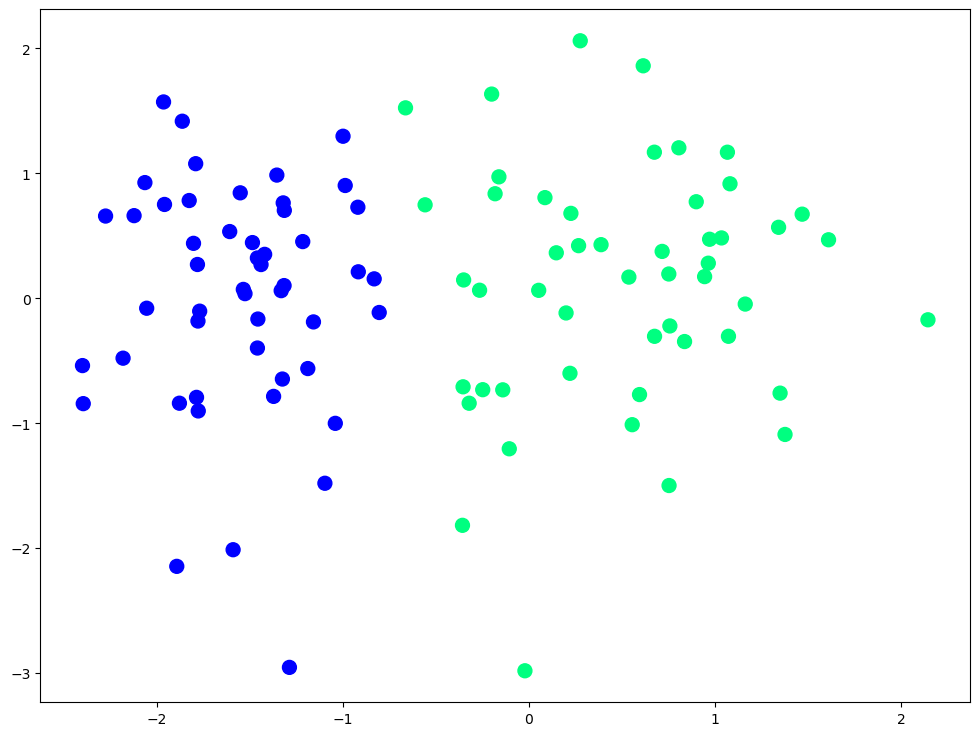

In [4]:
plt.figure(figsize=(12,9))
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.show()

In [5]:
def step(x):
    if(x>0):
        return 1
    return 0

In [6]:
def perceptron(x,y):
    x=np.insert(x,0,1,axis=1)
    weights=np.ones(x.shape[1])
    lr=0.1

    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(x[j],weights)) # s
        weights=weights+lr*(y[j]-y_hat)*x[j]
    return weights[0],weights[1:]

In [7]:
intercept,coef=perceptron(x,y)

In [8]:
print(intercept)
print(coef)

1.0
[1.34210293 0.2549306 ]


In [9]:
m= -(coef[0]/coef[1])
b= -(intercept / coef[1])
print(m)
print(b)

-5.264581472133879
-3.922636144424579


In [10]:
x_input=np.linspace(-3,3,100)
y_input=m * x_input + b

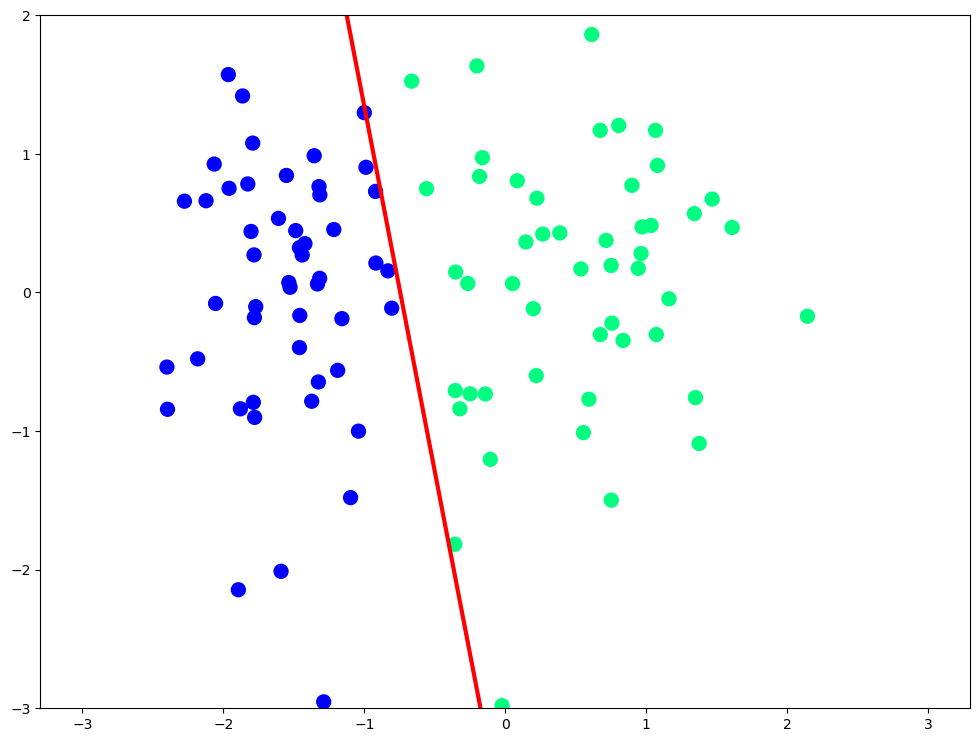

In [11]:
plt.figure(figsize=(12,9))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()


# how logisticRegression implemented in scikit-learn is diff from perceptron trick?

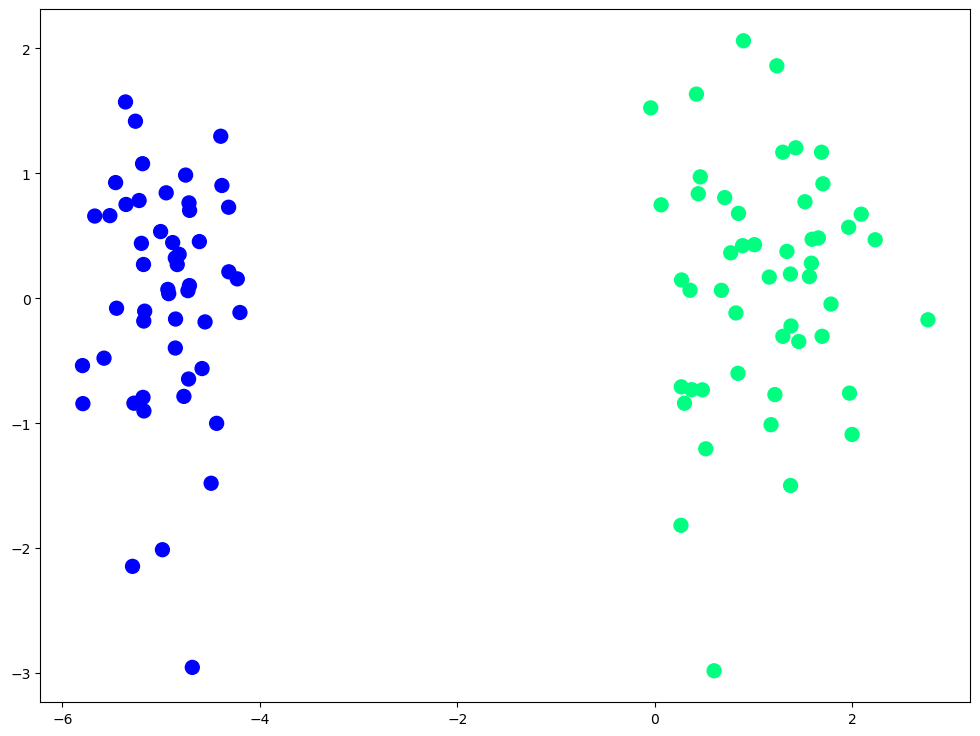

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
import numpy as np
x1,y1=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False
                        ,class_sep=30)
plt.figure(figsize=(12,9))
plt.scatter(x1[:,0],x1[:,1],c=y1,cmap='winter',s=100)
plt.show()

In [35]:
intercept,coef=perceptron(x1,y1)

In [36]:
m= -(coef[0]/coef[1])
b= -(intercept / coef[1])
print(m)
print(b)

-2.0890764668062958
-2.3066116207171747


In [37]:
x_input=np.linspace(-3,3,100)
y_input=m * x_input + b

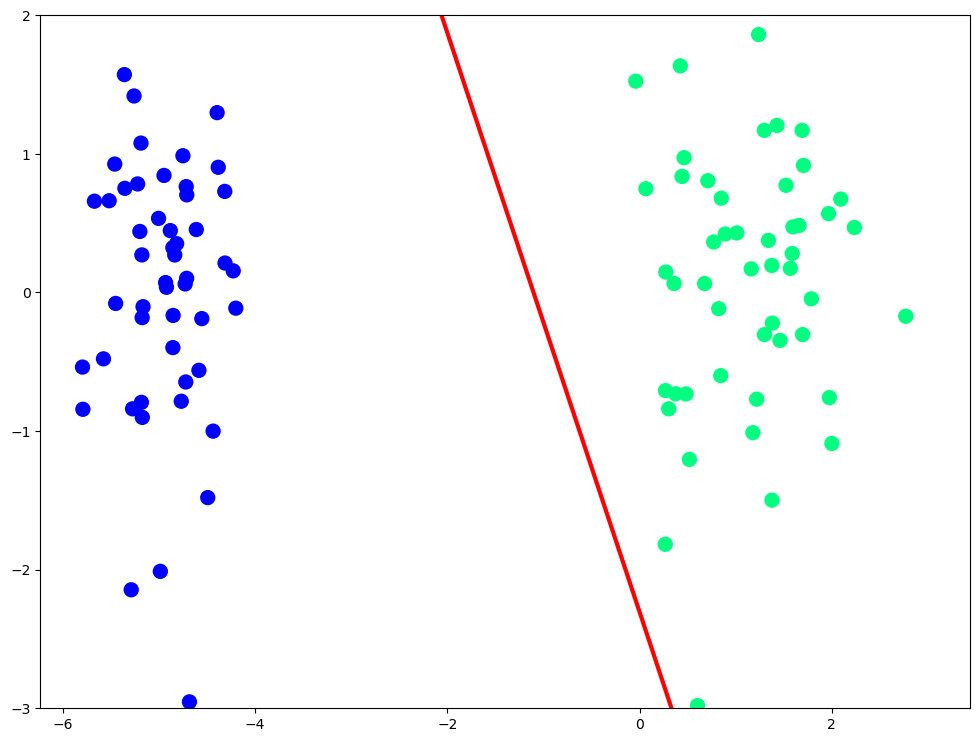

In [38]:
plt.figure(figsize=(12,9))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(x1[:,0],x1[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()


In [39]:
lor=LogisticRegression()
lor.fit(x1,y1)

LogisticRegression()

In [40]:
lor.coef_

array([[1.77255101, 0.01190507]])

In [41]:
m= - (lor.coef_[0][0] / lor.coef_[0][1])
b= -(lor.intercept_ / lor.coef_[0][1])

In [42]:
x1_input=np.linspace(-3,3,100)
y1_input=m * x1_input + b

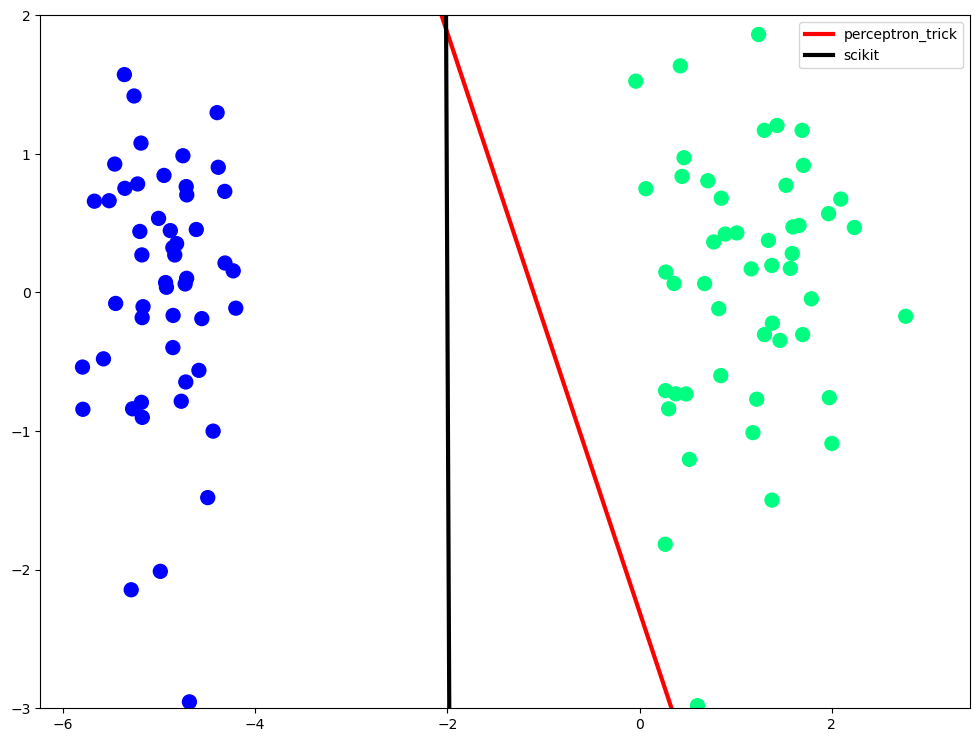

In [43]:
plt.figure(figsize=(12,9))
plt.plot(x_input,y_input,color='red',linewidth=3,label='perceptron_trick')
plt.plot(x1_input,y1_input,color='black',linewidth=3,label='scikit')
plt.scatter(x1[:,0],x1[:,1],c=y1,cmap='winter',s=100)
plt.ylim(-3,2)
plt.legend()
plt.show()


# perceptron trick do not improve once the miss-classifying points becomes zero -> (overfitting chances)
# whereas scikit implementation tries to attain the best fit line.